# LAB 3.1 - TDNN and RNN for NARMA10

This notebook performs model selection, retraining and test evaluation for TDNN and RNN.


In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

import yaml
import torch
from torch import nn

from data_utils import (
    load_narma10,
    make_rnn_tensors,
    make_tdnn_tensors,
    plot_loss_curves,
    plot_prediction_slice,
    plot_series_segment,
    save_metrics,
    split_series,
)
from search import rnn_random_search, tdnn_random_search


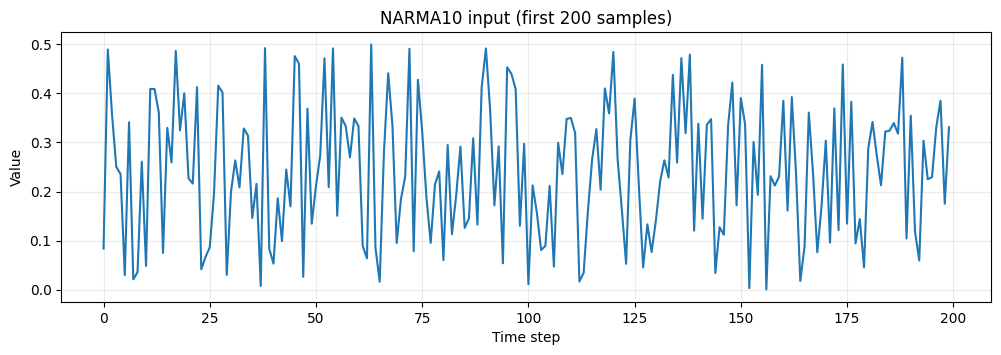

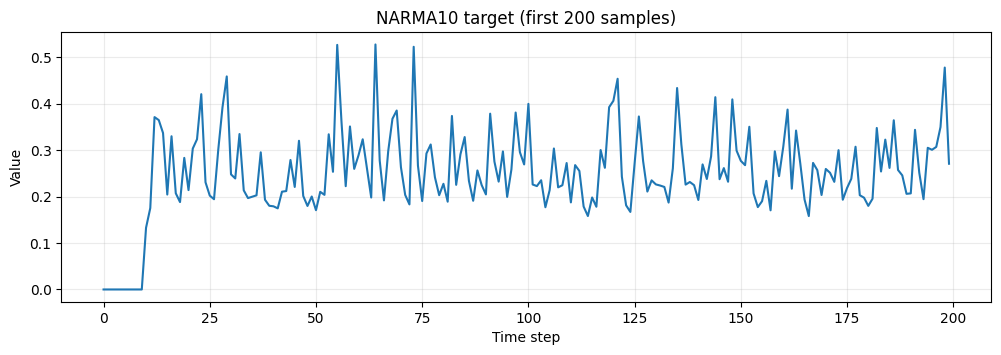

In [8]:
x, y = load_narma10(PROJECT_ROOT / "data" / "NARMA10.csv")
plot_series_segment(x, "NARMA10 input (first 200 samples)")
plot_series_segment(y, "NARMA10 target (first 200 samples)")

x_train, x_val, x_test, y_train, y_val, y_test = split_series(x, y, train_size=4000, val_size=1000)


## TDNN


In [9]:
with open(PROJECT_ROOT / "configs" / "tdnn_small.yaml", "r", encoding="utf-8") as fp:
    tdnn_small = yaml.safe_load(fp)
with open(PROJECT_ROOT / "configs" / "tdnn_deep.yaml", "r", encoding="utf-8") as fp:
    tdnn_deep = yaml.safe_load(fp)

xt, xv, xte, yt, yv, yte = make_tdnn_tensors((x_train, x_val, x_test), (y_train, y_val, y_test))

tdnn_trials = 500
best_tdnn = tdnn_random_search(
    spaces=[tdnn_small, tdnn_deep],
    n_iter=tdnn_trials,
    x_train=xt,
    y_train=yt,
    x_val=xv,
    y_val=yv,
    seed=42,
)

print("Best TDNN trial:", best_tdnn["trial"])
print("Best TDNN params:")
for k, v in best_tdnn["params"].items():
    print(f"  {k}: {v}")


Best TDNN trial: 283
Best TDNN params:
  conv_channels: [16, 32, 64, 128]
  kernel_sizes: [3, 3, 5, 7]
  dilations: [1, 2, 3, 4]
  strides: [1, 1, 1, 1]
  activations: ['ReLU', 'ReLU', 'ReLU', 'ReLU']
  fc_hidden: 32
  lr: 0.01
  weight_decay: 1e-05
  epochs: 250
  patience: 100
  min_delta: 1e-7


TDNN train MSE: 0.00035591
TDNN val   MSE: 0.00040957


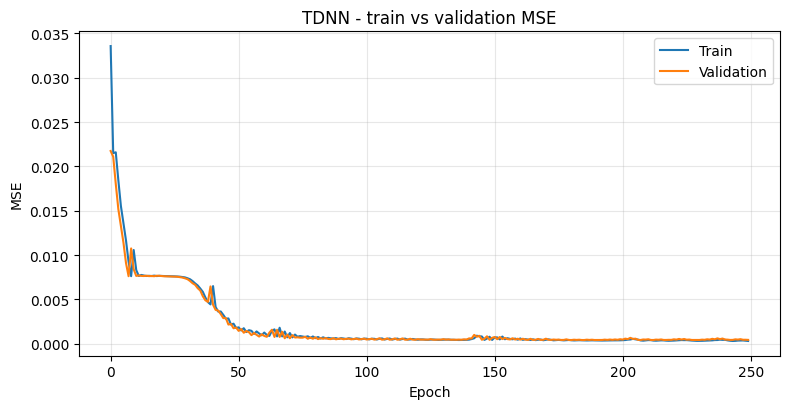

In [10]:
tdnn_model = best_tdnn["model"]
loss_fn = nn.MSELoss()

tdnn_train_mse = float(loss_fn(tdnn_model(xt), yt).item())
tdnn_val_mse = float(loss_fn(tdnn_model(xv), yv).item())

print(f"TDNN train MSE: {tdnn_train_mse:.8f}")
print(f"TDNN val   MSE: {tdnn_val_mse:.8f}")

plot_loss_curves(
    best_tdnn["train_history"],
    best_tdnn["val_history"],
    title="TDNN - train vs validation MSE",
    path=PROJECT_ROOT / "figures" / "tdnn_train_val_loss.png",
)


TDNN retrain MSE: 0.00007036
TDNN test    MSE: 0.00018646


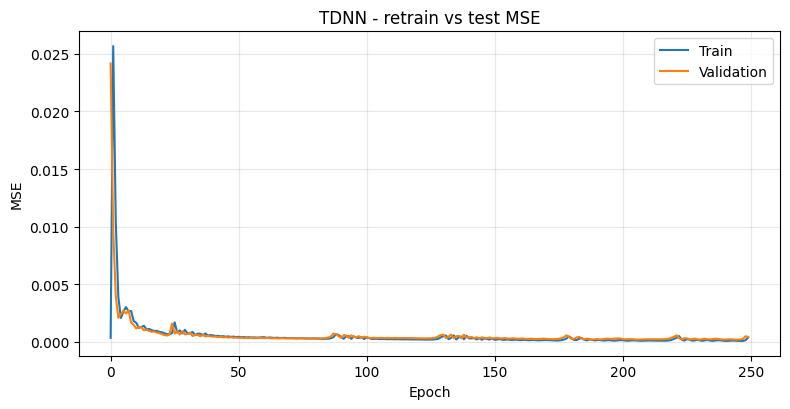

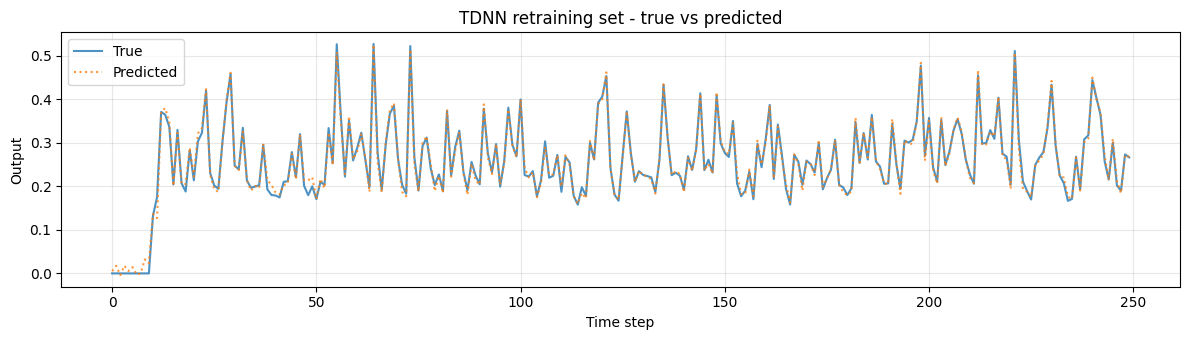

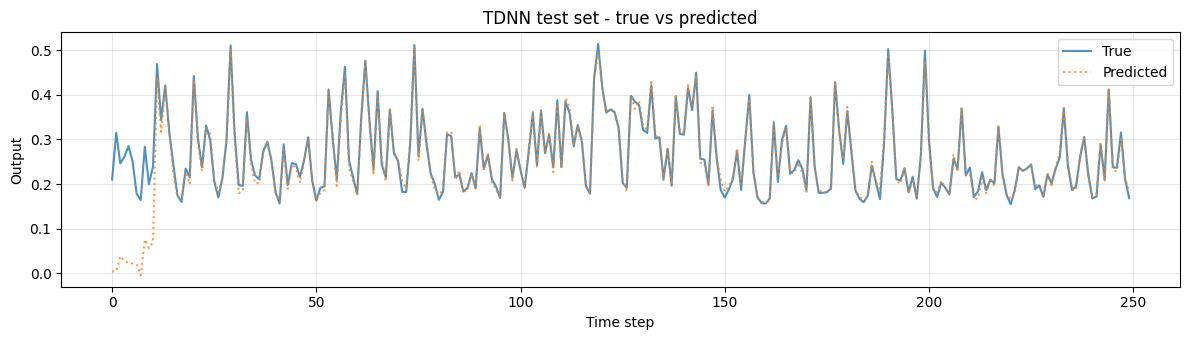

In [11]:
x_re = torch.cat([xt, xv], dim=2)
y_re = torch.cat([yt, yv], dim=1)

ret_hist, test_hist = tdnn_model.fit(
    x_train=x_re,
    y_train=y_re,
    x_val=xte,
    y_val=yte,
    epochs=int(best_tdnn["params"]["epochs"]),
    lr=float(best_tdnn["params"]["lr"]),
    weight_decay=float(best_tdnn["params"]["weight_decay"]),
    patience=int(best_tdnn["params"]["patience"]),
    min_delta=float(best_tdnn["params"]["min_delta"]),
)

tdnn_retrain_mse = float(loss_fn(tdnn_model(x_re), y_re).item())
tdnn_test_mse = float(loss_fn(tdnn_model(xte), yte).item())

print(f"TDNN retrain MSE: {tdnn_retrain_mse:.8f}")
print(f"TDNN test    MSE: {tdnn_test_mse:.8f}")

plot_loss_curves(
    ret_hist,
    test_hist,
    title="TDNN - retrain vs test MSE",
    path=PROJECT_ROOT / "figures" / "tdnn_retrain_test_loss.png",
)

plot_prediction_slice(
    y_re,
    tdnn_model(x_re),
    title="TDNN retraining set - true vs predicted",
    path=PROJECT_ROOT / "figures" / "tdnn_retrain_predictions.png",
)
plot_prediction_slice(
    yte,
    tdnn_model(xte),
    title="TDNN test set - true vs predicted",
    path=PROJECT_ROOT / "figures" / "tdnn_test_predictions.png",
)

torch.save(tdnn_model.state_dict(), PROJECT_ROOT / "results" / "tdnn_state_dict.pt")


## RNN


In [12]:
with open(PROJECT_ROOT / "configs" / "rnn.yaml", "r", encoding="utf-8") as fp:
    rnn_space = yaml.safe_load(fp)

xt, xv, xte, yt, yv, yte = make_rnn_tensors((x_train, x_val, x_test), (y_train, y_val, y_test))

rnn_trials = 75
best_rnn = rnn_random_search(
    space=rnn_space,
    n_iter=rnn_trials,
    x_train=xt,
    y_train=yt,
    x_val=xv,
    y_val=yv,
    seed=42,
)

print("Best RNN trial:", best_rnn["trial"])
print("Best RNN params:")
for k, v in best_rnn["params"].items():
    print(f"  {k}: {v}")


Best RNN trial: 28
Best RNN params:
  hidden_size: 128
  num_layers: 2
  nonlinearity: tanh
  dropout: 0.5
  bidirectional: False
  lr: 0.001
  weight_decay: 0.0
  epochs: 350
  patience: 15
  min_delta: 1e-15


RNN train MSE: 0.00142639
RNN val   MSE: 0.00139941


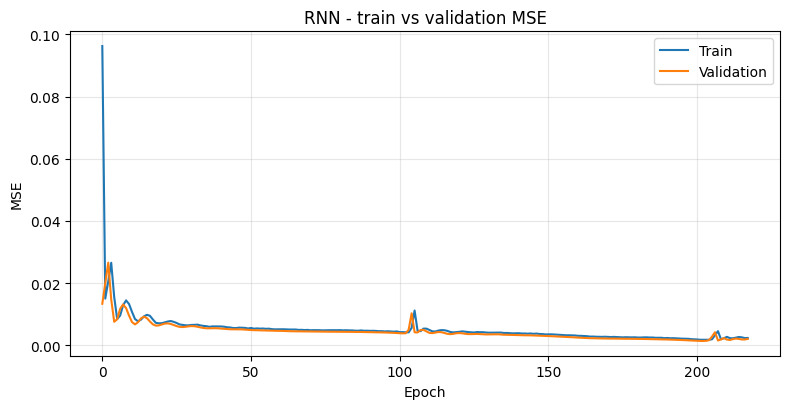

In [13]:
rnn_model = best_rnn["model"]
loss_fn = nn.MSELoss()

rnn_train_mse = float(loss_fn(rnn_model(xt)[0], yt).item())
rnn_val_mse = float(loss_fn(rnn_model(xv)[0], yv).item())

print(f"RNN train MSE: {rnn_train_mse:.8f}")
print(f"RNN val   MSE: {rnn_val_mse:.8f}")

plot_loss_curves(
    best_rnn["train_history"],
    best_rnn["val_history"],
    title="RNN - train vs validation MSE",
    path=PROJECT_ROOT / "figures" / "rnn_train_val_loss.png",
)


RNN retrain MSE: 0.00116932
RNN test    MSE: 0.00109414


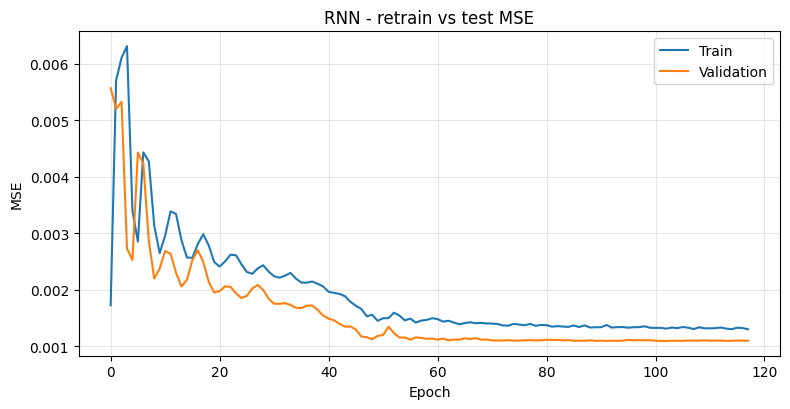

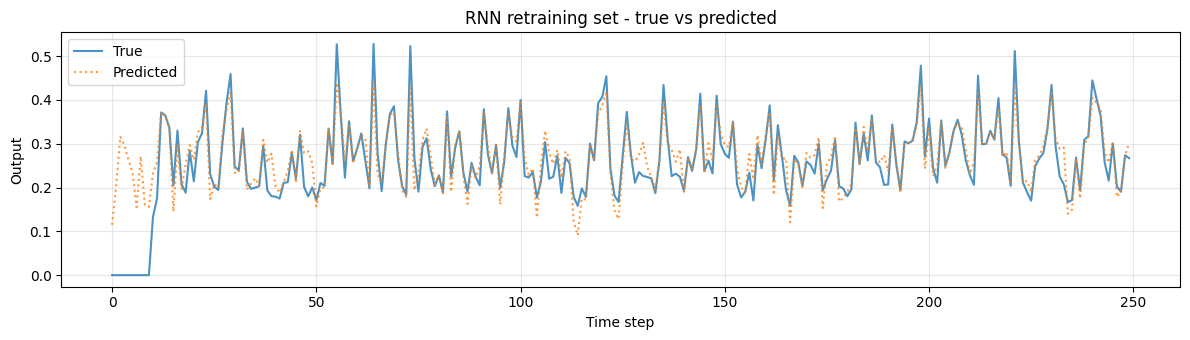

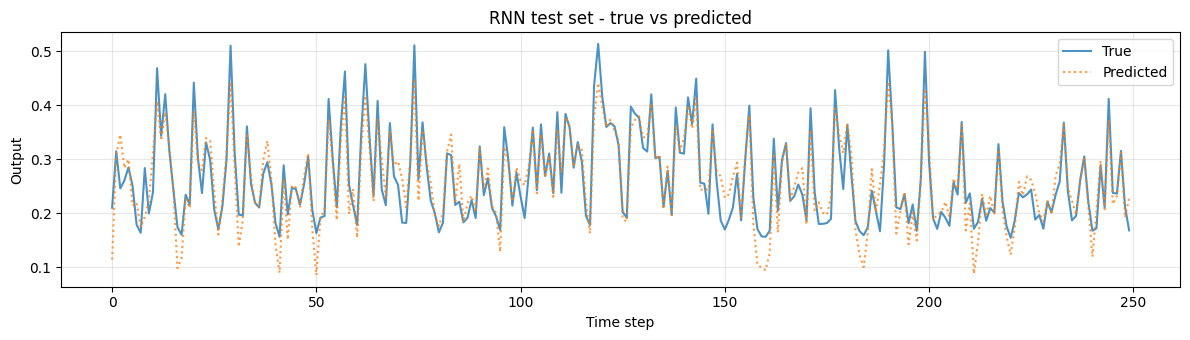

In [14]:
x_re = torch.cat([xt, xv], dim=1)
y_re = torch.cat([yt, yv], dim=1)

ret_hist, test_hist = rnn_model.fit(
    x_train=x_re,
    y_train=y_re,
    x_val=xte,
    y_val=yte,
    epochs=int(best_rnn["params"]["epochs"]),
    lr=float(best_rnn["params"]["lr"]),
    weight_decay=float(best_rnn["params"]["weight_decay"]),
    patience=int(best_rnn["params"]["patience"]),
    min_delta=float(best_rnn["params"]["min_delta"]),
)

rnn_retrain_pred, _ = rnn_model(x_re)
rnn_test_pred, _ = rnn_model(xte)

rnn_retrain_mse = float(loss_fn(rnn_retrain_pred, y_re).item())
rnn_test_mse = float(loss_fn(rnn_test_pred, yte).item())

print(f"RNN retrain MSE: {rnn_retrain_mse:.8f}")
print(f"RNN test    MSE: {rnn_test_mse:.8f}")

plot_loss_curves(
    ret_hist,
    test_hist,
    title="RNN - retrain vs test MSE",
    path=PROJECT_ROOT / "figures" / "rnn_retrain_test_loss.png",
)

plot_prediction_slice(
    y_re,
    rnn_retrain_pred,
    title="RNN retraining set - true vs predicted",
    path=PROJECT_ROOT / "figures" / "rnn_retrain_predictions.png",
)
plot_prediction_slice(
    yte,
    rnn_test_pred,
    title="RNN test set - true vs predicted",
    path=PROJECT_ROOT / "figures" / "rnn_test_predictions.png",
)

torch.save(rnn_model.state_dict(), PROJECT_ROOT / "results" / "rnn_state_dict.pt")


In [15]:
save_metrics(
    PROJECT_ROOT / "results" / "tdnn_metrics.txt",
    {
        "validation_mse": best_tdnn["val_loss"],
        "retrain_mse": tdnn_retrain_mse,
        "test_mse": tdnn_test_mse,
        "search_trials": 500.0,
    },
    header="TDNN Summary",
)

save_metrics(
    PROJECT_ROOT / "results" / "rnn_metrics.txt",
    {
        "validation_mse": best_rnn["val_loss"],
        "retrain_mse": rnn_retrain_mse,
        "test_mse": rnn_test_mse,
        "search_trials": 75.0,
    },
    header="RNN Summary",
)
